In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D, MaxPooling2D
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive/Colab\ Notebooks/COGS\ 189/

/content/drive/MyDrive/Colab Notebooks/COGS 189


In [ ]:
data = pd.read_csv("eeg_data.csv")

In [ ]:
data.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [ ]:
eeg_data_columns = data.columns.values.tolist()

In [ ]:
print(data["label"].value_counts())
cleanup_rules = ({'NEUTRAL': 0, 'POSITIVE': 1, 'NEGATIVE': 2} )
eeg_data_encoded = data.replace(cleanup_rules, inplace=False)
print(eeg_data_encoded['label'].value_counts())

label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64
label
0    716
2    708
1    708
Name: count, dtype: int64


In [ ]:
eeg_data_encoded.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,2
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,0
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,1
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,1
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,0


In [ ]:
eeg_data_cor = eeg_data_encoded[['fft_36_a','fft_39_a',
 'fft_369_a',
 'fft_366_a',
 'fft_89_a',
 'fft_86_a',
 'fft_50_a',
 'fft_644_b',
 'fft_641_b',
 'fft_685_b',
 'fft_265_a',
 'fft_73_b',
 'fft_72_b',
 'fft_447_a',
 'fft_448_a',
 'fft_448_b',
 'fft_447_b',
 'fft_431_b',
 'fft_434_b',
 'fft_329_b',
 'fft_326_b',
 'fft_701_a',
 'fft_704_a',
 'fft_284_a',
 'fft_281_a',
 'fft_56_b',
 'fft_59_b',
 'fft_72_a',
 'fft_73_a',
 'fft_644_a',
 'fft_641_a',
 'fft_426_b',
 'fft_429_b',
 'fft_266_b',
 'fft_269_b',
 'fft_685_a',
 'fft_434_a',
 'fft_431_a',
 'fft_329_a',
 'fft_326_a',
 'fft_389_b',
 'fft_386_b',
 'fft_463_b',
 'fft_462_b',
 'fft_310_b',
 'fft_59_a',
 'fft_56_a',
 'fft_371_b',
 'fft_374_b',
 'fft_745_b',
 'fft_88_b',
 'fft_87_b',
 'fft_14_b',
 'fft_11_b',
 'fft_426_a',
 'fft_429_a',
 'fft_626_b',
 'fft_629_b',
 'fft_463_a',
 'fft_462_a',
 'fft_266_a',
 'fft_269_a',
 'fft_54_b',
 'fft_51_b',
 'fft_87_a',
 'fft_88_a',
 'fft_700_b',
 'fft_374_a',
 'fft_371_a',
 'fft_310_a',
 'fft_14_a',
 'fft_11_a',
 'fft_629_a',
 'fft_626_a',
 'fft_386_a',
 'fft_389_a',
 'fft_565_b',
 'fft_671_b',
 'fft_674_b',
 'fft_716_b',
 'fft_719_b',
 'fft_745_a',
 'fft_74_b',
 'fft_71_b',
 'fft_446_b',
 'fft_449_b',
 'fft_51_a',
 'fft_54_a',
 'min_q_15_b',
 'min_q_18_b',
 'fft_700_a',
 'fft_734_b',
 'fft_731_b',
 'fft_115_b',
 'fft_446_a',
 'fft_449_a',
 'fft_190_b',
 'min_q_15_a',
 'fft_325_b',
 'min_q_18_a',
 'fft_71_a',
 'fft_74_a',
 'fft_565_a',
 'fft_611_b',
 'fft_614_b',
 'fft_580_b',
 'fft_254_b',
 'fft_251_b',
 'fft_490_b',
 'fft_115_a',
 'fft_715_b',
 'fft_686_b',
 'fft_689_b',
 'fft_655_b',
 'fft_716_a',
 'fft_719_a',
 'min_q_5_b',
 'fft_671_a',
 'fft_674_a',
 'fft_734_a',
 'fft_731_a',
 'fft_401_b',
 'fft_404_b',
 'fft_299_b',
 'fft_296_b',
 'fft_190_a',
 'fft_625_b',
 'fft_490_a',
 'fft_325_a',
 'fft_655_a',
 'fft_341_b',
 'fft_344_b',
 'fft_520_b',
 'fft_251_a',
 'fft_254_a',
 'fft_419_b',
 'fft_416_b',
 'fft_611_a',
 'fft_614_a',
 'fft_236_b',
 'fft_239_b',
 'fft_715_a',
 'fft_359_b',
 'fft_356_b',
 'fft_689_a',
 'fft_686_a',
 'fft_580_a',
 'fft_370_b',
 'min_q_8_b',
 'fft_314_b',
 'fft_311_b',
 'fft_29_b',
 'fft_26_b',
 'fft_296_a',
 'fft_299_a',
 'fft_341_a',
 'fft_344_a',
 'fft_625_a',
 'fft_404_a',
 'fft_401_a',
 'fft_205_b',
 'fft_670_b',
 'fft_44_b',
 'fft_41_b',
 'fft_280_b',
 'fft_520_a',
 'fft_29_a',
 'fft_26_a',
 'fft_145_b',
 'fft_416_a',
 'fft_419_a',
 'fft_340_b',
 'fft_239_a',
 'fft_236_a',
 'fft_359_a',
 'fft_356_a',
 'fft_730_b',
 'fft_205_a',
 'fft_311_a',
 'fft_314_a',
 'fft_550_b',
 'fft_41_a',
 'fft_44_a',
 'fft_370_a',
 'fft_145_a',
 'fft_475_b',
 'fft_250_b',
 'fft_280_a',
 'fft_100_b',
 'fft_505_b',
 'min_q_5_a',
 'fft_730_a',
 'fft_340_a',
 'fft_670_a',
 'fft_100_a',
 'fft_550_a',
 'fft_130_b',
 'fft_475_a',
 'fft_505_a',
 'fft_250_a',
 'fft_175_b',
 'fft_295_b',
 'fft_430_b',
 'fft_355_b',
 'min_q_8_a',
 'fft_130_a',
 'fft_460_b',
 'fft_55_b',
 'fft_175_a',
 'fft_85_b',
 'fft_430_a',
 'fft_70_b',
 'fft_415_b',
 'fft_445_b',
 'fft_295_a',
 'fft_460_a',
 'fft_55_a',
 'fft_355_a',
 'fft_445_a',
 'fft_70_a',
 'fft_40_b',
 'fft_85_a',
 'fft_415_a',
 'fft_385_b',
 'fft_40_a',
 'fft_10_b',
 'mean_0_b',
 'fft_385_a',
 'fft_10_a',
 '# mean_0_a',
 'fft_618_b',
 'fft_617_b',
 'fft_617_a',
 'fft_618_a',
 'fft_242_b',
 'fft_243_b',
 'fft_243_a',
 'fft_242_a',
 'fft_400_b',
 'fft_25_b',
 'fft_25_a',
 'fft_400_a',
 'fft_737_a',
 'fft_738_a',
 'fft_738_b',
 'fft_737_b',
 'fft_363_b',
 'fft_362_b',
 'fft_363_a',
 'fft_362_a',
 'fft_632_b',
 'fft_633_b',
 'fft_632_a',
 'fft_633_a',
 'fft_258_b',
 'fft_257_b',
 'fft_257_a',
 'fft_258_a',
 'fft_152_a',
 'fft_153_a',
 'fft_152_b',
 'fft_153_b',
 'fft_647_b',
 'fft_648_b',
 'fft_647_a',
 'fft_648_a',
 'fft_273_a',
 'fft_272_a',
 'fft_273_b',
 'fft_272_b',
 'fft_332_b',
 'fft_333_b',
 'fft_527_a',
 'fft_528_a',
 'fft_527_b',
 'fft_528_b',
 'fft_707_a',
 'fft_708_a',
 'fft_348_b',
 'fft_347_b',
 'fft_723_a',
 'fft_722_a',
 'fft_707_b',
 'fft_708_b',
 'fft_333_a',
 'fft_332_a',
 'fft_723_b',
 'fft_722_b',
 'fft_348_a',
 'fft_347_a',
 'fft_693_b',
 'fft_692_b',
 'fft_692_a',
 'fft_693_a',
 'fft_378_b',
 'fft_377_b',
 'fft_318_b',
 'fft_317_b',
 'fft_377_a',
 'fft_378_a',
 'fft_318_a',
 'fft_317_a',
 'covmat_20_b',
 'covmat_97_b',
 'covmat_97_a',
 'covmat_20_a',
 'fft_602_a',
 'fft_603_a',
 'fft_602_b',
 'fft_603_b',
 'fft_228_b',
 'fft_227_b',
 'fft_228_a',
 'fft_227_a',
 'fft_47_a',
 'fft_48_a',
 'fft_423_a',
 'fft_422_a',
 'fft_48_b',
 'fft_47_b',
 'fft_407_b',
 'fft_408_b',
 'fft_423_b',
 'fft_422_b',
 'fft_662_a',
 'fft_663_a',
 'fft_663_b',
 'fft_662_b',
 'fft_407_a',
 'fft_408_a',
 'fft_32_a',
 'fft_33_a',
 'fft_288_a',
 'fft_287_a',
 'fft_32_b',
 'fft_33_b',
 'fft_288_b',
 'fft_287_b',
 'fft_62_a',
 'fft_63_a',
 'fft_437_a',
 'fft_438_a',
 'fft_437_b',
 'fft_438_b',
 'fft_63_b',
 'fft_62_b',
 'fft_123_a',
 'fft_122_a',
 'fft_123_b',
 'fft_122_b',
 'fft_498_a',
 'fft_497_a',
 'fft_497_b',
 'fft_498_b',
 'fft_573_a',
 'fft_572_a',
 'fft_17_a',
 'fft_18_a',
 'fft_573_b',
 'fft_572_b',
 'fft_18_b',
 'fft_17_b',
 'fft_197_b',
 'fft_198_b',
 'fft_392_b',
 'fft_393_b',
 'fft_197_a',
 'fft_198_a',
 'fft_393_a',
 'fft_392_a',
 'fft_212_b',
 'fft_213_b',
 'fft_138_a',
 'fft_137_a',
 'fft_213_a',
 'fft_212_a',
 'fft_588_b',
 'fft_587_b',
 'fft_588_a',
 'fft_587_a',
 'fft_138_b',
 'fft_137_b',
 'fft_513_b',
 'fft_512_b',
 'fft_513_a',
 'fft_512_a',
 'fft_302_b',
 'fft_303_b',
 'fft_678_a',
 'fft_677_a',
 'fft_303_a',
 'fft_302_a',
 'fft_677_b',
 'fft_678_b',
 'fft_107_a',
 'fft_108_a',
 'fft_108_b',
 'fft_107_b',
 'fft_2_a',
 'fft_3_a',
 'fft_77_a',
 'fft_78_a',
 'fft_2_b',
 'fft_3_b',
 'fft_482_a',
 'fft_483_a',
 'fft_511_b',
 'fft_514_b',
 'fft_77_b',
 'fft_78_b',
 'fft_482_b',
 'fft_483_b',
 'fft_136_a',
 'fft_139_a',
 'fft_136_b',
 'fft_139_b',
 'fft_168_b',
 'fft_167_b',
 'fft_167_a',
 'fft_168_a',
 'fft_514_a',
 'fft_511_a',
 'fft_543_a',
 'fft_542_a',
 'fft_452_a',
 'fft_453_a',
 'fft_543_b',
 'fft_542_b',
 'fft_183_a',
 'fft_182_a',
 'fft_452_b',
 'fft_453_b',
 'fft_182_b',
 'fft_183_b',
 'fft_169_b',
 'fft_166_b',
 'fft_169_a',
 'fft_166_a',
 'fft_541_a',
 'fft_544_a',
 'fft_544_b',
 'fft_541_b',
 'fft_558_a',
 'fft_557_a',
 'fft_557_b',
 'fft_558_b',
 'fft_92_a',
 'fft_93_a',
 'fft_93_b',
 'fft_92_b',
 'fft_499_b',
 'fft_496_b',
 'fft_496_a',
 'fft_499_a',
 'fft_121_b',
 'fft_124_b',
 'fft_556_b',
 'fft_559_b',
 'fft_181_b',
 'fft_184_b',
 'fft_556_a',
 'fft_559_a',
 'fft_121_a',
 'fft_124_a',
 'fft_184_a',
 'fft_181_a',
 'logm_1_b',
 'fft_529_b',
 'fft_526_b',
 'fft_154_b',
 'fft_151_b',
 'fft_151_a',
 'fft_154_a',
 'fft_467_a',
 'fft_468_a',
 'fft_529_a',
 'fft_526_a',
 'fft_468_b',
 'fft_467_b',
 'covmat_116_b',
 'covmat_105_b',
 'covmat_116_a',
 'covmat_105_a',
 'fft_586_b',
 'fft_589_b',
 'fft_211_b',
 'fft_214_b',
 'fft_240_b',
 'fft_214_a',
 'fft_211_a',
 'fft_240_a',
 'fft_615_b',
 'fft_586_a',
 'fft_589_a',
 'fft_615_a',
 'fft_481_b',
 'fft_484_b',
 'fft_484_a',
 'fft_481_a',
 'fft_106_b',
 'fft_109_b',
 'fft_109_a',
 'fft_106_a',
 'fft_600_b',
 'fft_225_b',
 'fft_600_a',
 'fft_604_b',
 'fft_601_b',
 'fft_226_b',
 'fft_229_b',
 'fft_225_a',
 'fft_195_b',
 'fft_570_b',
 'fft_601_a',
 'fft_604_a',
 'fft_570_a',
 'fft_229_a',
 'fft_226_a',
 'fft_195_a',
 'fft_525_b',
 'fft_150_b',
 'fft_150_a',
 'logm_1_a',
 'fft_91_b',
 'fft_94_b',
 'fft_525_a',
 'fft_466_b',
 'fft_469_b',
 'fft_94_a',
 'fft_91_a',
 'fft_466_a',
 'fft_469_a',
 'fft_649_b',
 'fft_646_b',
 'fft_436_b',
 'fft_439_b',
 'fft_646_a',
 'fft_649_a',
 'fft_274_b',
 'fft_271_b',
 'fft_271_a',
 'fft_274_a',
 'fft_436_a',
 'fft_439_a',
 'fft_64_a',
 'fft_61_a',
 'fft_64_b',
 'fft_61_b',
 'fft_165_b',
 'fft_165_a',
 'fft_679_b',
 'fft_676_b',
 'fft_255_b',
 'fft_180_b',
 'fft_571_b',
 'fft_574_b',
 'fft_330_b',
 'fft_540_a',
 'fft_555_b',
 'fft_180_a',
 'fft_196_b',
 'fft_199_b',
 'fft_540_b',
 'fft_304_b',
 'fft_301_b',
 'fft_574_a',
 'fft_571_a',
 'fft_705_a',
 'fft_210_b',
 'fft_705_b',
 'fft_664_a',
 'fft_661_a',
 'fft_555_a',
 'fft_630_b',
 'fft_286_b',
 'fft_289_b',
 'fft_376_b',
 'fft_379_b',
 'fft_255_a',
 'fft_661_b',
 'fft_664_b',
 'fft_331_b',
 'fft_334_b',
 'fft_376_a',
 'fft_379_a',
 'fft_304_a',
 'fft_301_a',
 'fft_196_a',
 'fft_199_a',
 'fft_676_a',
 'fft_679_a',
 'fft_210_a',
 'fft_585_b',
 'fft_454_a',
 'fft_451_a',
 'fft_330_a',
 'fft_451_b',
 'fft_454_b',
 'fft_76_a',
 'fft_79_a',
 'fft_709_b',
 'fft_706_b',
 'fft_79_b',
 'fft_76_b',
 'fft_706_a',
 'fft_709_a',
 'fft_289_a',
 'fft_286_a',
 'fft_585_a',
 'fft_331_a',
 'fft_334_a',
 'fft_630_a',
 'fft_616_b',
 'fft_619_b',
 'fft_259_b',
 'fft_256_b',
 'fft_394_b',
 'fft_391_b',
 'fft_241_b',
 'fft_244_b',
 'fft_244_a',
 'fft_241_a',
 'fft_619_a',
 'fft_616_a',
 'fft_634_b',
 'fft_631_b',
 'fft_256_a',
 'fft_259_a',
 'fft_16_b',
 'fft_19_b',
 'fft_285_b',
 'fft_391_a',
 'fft_394_a',
 'fft_660_a',
 'fft_19_a',
 'fft_16_a',
 'fft_660_b',
 'fft_634_a',
 'fft_631_a',
 'fft_349_b',
 'fft_346_b',
 'fft_285_a',
 'fft_120_b',
 'fft_346_a',
 'fft_349_a',
 'fft_645_b',
 'fft_495_b',
 'fft_495_a',
 'fft_120_a',
 'fft_270_a',
 'fft_270_b',
 'fft_724_b',
 'fft_721_b',
 'fft_721_a',
 'fft_724_a',
 'fft_645_a',
 'fft_60_a',
 'fft_435_b',
 'fft_135_a',
 'fft_435_a',
 'fft_345_b',
 'fft_60_b',
 'fft_135_b',
 'fft_736_b',
 'fft_739_b',
 'fft_510_b',
 'fft_510_a',
 'fft_720_b',
 'fft_720_a',
 'fft_739_a',
 'fft_736_a',
 'fft_424_b',
 'fft_421_b',
 'fft_694_b',
 'fft_691_b',
 'fft_316_b',
 'fft_319_b',
 'fft_364_b',
 'fft_361_b',
 'fft_345_a',
 'fft_421_a',
 'fft_424_a',
 'fft_46_b',
 'fft_49_b',
 'fft_319_a',
 'fft_316_a',
 'fft_480_b',
 'fft_480_a',
 'fft_694_a',
 'fft_691_a',
 'fft_364_a',
 'fft_361_a',
 'fft_105_b',
 'fft_375_b',
 'fft_49_a',
 'fft_46_a',
 'fft_675_b',
 'fft_105_a',
 'fft_735_b',
 'fft_375_a',
 'eigen_0_b',
 'fft_300_b',
 'fft_690_b',
 'fft_735_a',
 'eigen_0_a',
 'fft_675_a',
 'fft_315_b',
 'fft_360_b',
 'fft_300_a',
 'fft_690_a',
 'fft_315_a',
 'fft_360_a',
 'fft_406_b',
 'fft_409_b',
 'fft_4_a',
 'fft_1_a',
 'fft_4_b',
 'fft_1_b',
 'fft_406_a',
 'fft_409_a',
 'fft_34_b',
 'fft_31_b',
 'fft_31_a',
 'fft_34_a',
 'logm_24_b',
 'fft_405_b',
 'logm_24_a',
 'fft_75_a',
 'fft_75_b',
 'fft_405_a',
 'fft_450_b',
 'fft_450_a',
 'fft_390_b',
 'fft_465_b',
 'fft_15_b',
 'fft_420_b',
 'fft_30_a',
 'fft_30_b',
 'fft_15_a',
 'fft_90_b',
 'fft_390_a',
 'fft_465_a',
 'fft_45_b',
 'fft_90_a',
 'fft_420_a',
 'fft_45_a',
 'fft_0_a',
 'fft_0_b',
 'covmat_117_b',
 'covmat_117_a',
 'mean_d_17_b',
 'mean_d_7_b',
 'mean_d_17_a',
 'mean_d_7_a',
 'mean_d_12_b',
 'mean_d_12_a',
 'mean_d_2_b2',
 'mean_d_2_a2',
 'mean_2_b',
 'mean_2_a',
 'logm_8_b',
 'logm_8_a',
 'logm_9_b',
 'logm_9_a',
 'entropy3_b',
 'entropy3_a',
 'entropy0_b',
 'entropy0_a',
 'logm_0_b',
 'logm_0_a',
 'covmat_104_b',
 'covmat_104_a',
 'stddev_2_b',
 'stddev_2_a',
 'min_q_12_b',
 'min_q_12_a',
 'min_q_2_b',
 'min_q_2_a',
 'min_q_17_b',
 'min_q_7_b','min_q_17_a','min_q_7_a','min_2_b','min_2_a','label']]

In [ ]:
eeg_data_cor.head()

,fft_36_a,fft_39_a,fft_369_a,fft_366_a,fft_89_a,fft_86_a,fft_50_a,fft_644_b,fft_641_b,fft_685_b,...,min_q_12_a,min_q_2_b,min_q_2_a,min_q_17_b,min_q_7_b,min_q_17_a,min_q_7_a,min_2_b,min_2_a,label
0,-75.1,-75.1,170.00,170.00,428.0,428.0,29.8,345.0,345.0,-522.0,...,-698.0,-702.0,-677.0,-658.0,-727.0,-727.00,-676.000,-727.0,-727.000,2
1,22.8,22.8,0.84,0.84,17.5,17.5,87.4,-24.2,-24.2,120.0,...,16.3,16.0,11.1,13.5,12.7,12.00,-0.705,12.7,-0.705,0
2,432.0,432.0,465.00,465.00,361.0,361.0,-384.0,227.0,227.0,-210.0,...,-826.0,-814.0,-707.0,-743.0,-803.0,-822.00,-844.000,-814.0,-844.000,1
3,508.0,508.0,200.00,200.00,-26.5,-26.5,-364.0,-133.0,-133.0,258.0,...,-819.0,-820.0,-671.0,-552.0,-718.0,-712.00,-813.000,-820.0,-819.000,1
4,21.2,21.2,-6.85,-6.85,-32.2,-32.2,98.7,-31.7,-31.7,154.0,...,20.1,19.4,12.2,7.6,-12.3,-9.64,-5.480,-36.0,-9.640,0


In [ ]:
eeg_data_cor.iloc[3,1:].values.reshape(28,28).astype('uint8')

array([[252, 200, 200, 230, 230, 148, 123, 123,   2, 102, 188, 188, 185,
        185, 209, 209, 197, 197, 160, 160, 167, 167, 228, 228, 209, 209,
         21,  21],
       [  6,   6,  71,  71,   2,   2, 200, 209, 209,  19,  19, 111, 111,
          8,   8, 193,  93,  93, 187, 187, 132,  32,  32, 182, 182, 162,
        162,  85],
       [ 85,  35,  35,  42,  42, 161, 161,  22,  22, 185,   6,   6,  20,
         39,  39,   2,   2, 187, 187,  89, 209, 209, 110, 110,  16, 159,
        159,  38],
       [ 38,  22,  22, 232,   4, 244, 143, 143,  18, 159, 159, 164, 235,
        251,   4, 208, 208, 168, 141, 141,  11,   5,   5,  31, 251, 103,
        143, 143],
       [248,   4,   4, 235, 182, 182, 240, 240, 226, 226, 177, 177,   2,
         14,  15, 123,  13,  14,  14, 169, 168, 168, 225, 225,  77,  77,
         74,  74],
       [ 43, 228, 228, 193, 193, 227,   6,   4, 200, 200,  65,  65, 250,
        250,  97,  97, 226,  63,  63, 232, 241,  36,  36,   8, 208,  50,
         50, 211],
       [ 37,  37,  35,  80,  80,  34,  34,  66, 210, 231, 231, 138, 210,
        210, 110,  60, 252, 222,   5,  76, 169, 235, 248, 116,  28,  33,
        198, 242],
       [ 79, 245,  48, 202,  34, 173,   2, 250, 231, 182, 165, 200, 152,
        161, 222, 183, 129, 136, 149, 247, 147, 225,  46,  92,  13,  95,
        203, 239],
       [  2,  14,   5,  85,  14,  62,  62,  53,  53,  53,  53, 223, 223,
        166,   7, 205,   3, 201, 201, 251, 251, 191, 191, 254, 254, 216,
        216, 251],
       [251, 252, 252,   7,   7,  42,  42, 205, 205,  64,  64,  13,  13,
        186, 186,  12,  12,  22,  22, 203, 203, 242, 242,  26,  26,  34,
         34,  28],
       [ 28, 228, 228,  25,  25, 249, 249, 187, 187,  40,  40, 158, 158,
         49,  49, 161, 161, 236, 236, 215, 215,  80,  80,  72,  72,   1,
          1,   7],
       [  7,   1,   1,  17,  17,  14,  14, 209, 209, 204, 204, 239, 239,
          0,   0, 170, 170,  31,  31,  40,  40, 203, 203, 253, 253,  46,
         46, 172],
       [172, 175, 175, 243, 243, 225, 225, 246, 246, 249, 249,  10,  10,
          8,   8, 229, 229,  19,  19,  15,  15, 240, 240, 203, 203,  18,
         18, 179],
       [179,   0,   0, 210, 210, 192, 192, 210, 210, 218, 218,  14,  14,
        191, 191,  10,  10,  32,  32,  12,  12,  16,  16,  18,  18, 230,
        230, 236],
       [236,  13,  13, 200, 200,  10,  10,   6,   6,  12,  12, 202, 202,
        190, 190, 255, 255,  32,  32, 120, 120, 141, 141,  35,  35, 178,
        178, 142],
       [142,  36,  36,   1,   1, 209, 209,   4,   4, 233, 233, 222, 222,
        174, 174, 182, 182, 176, 176,  69,  69, 221, 221,  34,  34,  15,
         15,   8],
       [  8, 148, 148, 164, 164, 164, 164, 135, 135, 147, 147, 145, 145,
         45,  45, 167, 167,   5, 234, 234, 144, 144, 211, 211,   5,   5,
        143, 143],
       [215, 215, 112, 112, 140, 140, 142, 142, 129, 129, 156,  87,  87,
        235,   1, 126, 126, 161, 189, 189, 221, 221, 221, 221,  20,  20,
        247, 131],
       [126, 220, 220, 243, 243,  97, 139, 165, 246, 246, 135, 238, 238,
        155, 158, 213, 102,   5, 239, 239, 216,  35,  35,   4,   4, 239,
        239, 177],
       [177,  18,  18, 200, 200, 204, 204,  41,  41, 193, 193, 202, 202,
        192, 192, 199, 114, 236, 236, 248, 175,   9,   9, 101, 196,  54,
         19, 242],
       [242,  16, 152, 152, 244, 244, 109, 219, 192, 253, 253, 179, 216,
        249, 249, 238, 238,  47, 174, 174, 237, 237,  38,  38,  26,  26,
        226, 226],
       [146, 146, 215,  62,  23,  23, 214,  58,  58, 177, 177, 244, 244,
         23,  23, 229, 229,  21,  21, 223, 227, 227, 244, 166, 166, 198,
        198, 123],
       [123, 194, 194,  87,  87, 191, 191,   2,   2, 169, 169,  29,  29,
         12,  25,  25,   6, 209, 209, 187, 202, 202, 191, 191,  25,  30,
        238, 238],
       [147, 200,  33,   2, 196, 206, 249, 249, 201, 201, 211, 138,  44,
        145, 236, 168, 233,  84, 195, 195, 166,  80, 119, 159,  40,  40,
         45,  45],
       [158, 158,  80,  80,  53,  53,  2

In [ ]:
x_cor = eeg_data_cor.iloc[:,1:].values.reshape(len(eeg_data_cor),28,28,1)
y_cor = eeg_data_cor.iloc[:,-1].values

In [ ]:
x_cor_train, x_cor_test, y_cor_train, y_cor_test = train_test_split(x_cor,y_cor,test_size=0.2,random_state=4)

In [ ]:
print('Training data shape : ', x_cor_train.shape, y_cor_train.shape)

print('Testing data shape : ', x_cor_test.shape, y_cor_test.shape)

Training data shape :  (1705, 28, 28, 1) (1705,)
Testing data shape :  (427, 28, 28, 1) (427,)


In [ ]:
classes = np.unique(y_cor_train)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  3
Output classes :  [0 1 2]


In [ ]:
x_cor_train = x_cor_train.reshape(-1, 28,28, 1)
x_cor_test = x_cor_test.reshape(-1, 28,28, 1)
x_cor_train.shape, x_cor_test.shape

((1705, 28, 28, 1), (427, 28, 28, 1))

In [ ]:
x_cor_train = x_cor_train.astype('float32')
x_cor_test = x_cor_test.astype('float32')
x_cor_train = x_cor_train / 255.
x_cor_test = x_cor_test / 255.

In [ ]:
train_cor_Y_one_hot = to_categorical(y_cor_train)
test_cor_Y_one_hot = to_categorical(y_cor_test)
print('Original label:', y_cor_train[0])
print('After conversion to one-hot:', train_cor_Y_one_hot[0])

Original label: 0
After conversion to one-hot: [1. 0. 0.]


In [ ]:
from sklearn.model_selection import train_test_split
train_cor_X,valid_cor_X,train_cor_label,valid_cor_label = train_test_split(x_cor_train, train_cor_Y_one_hot, test_size=0.2, random_state=13)

In [ ]:
train_cor_X.shape,valid_cor_X.shape,train_cor_label.shape,valid_cor_label.shape

((1364, 28, 28, 1), (341, 28, 28, 1), (1364, 3), (341, 3))

In [ ]:
batch_size = 64
epochs = 100
num_classes = 3

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import LeakyReLU

In [ ]:
model_cor = Sequential()
model_cor.add(Conv2D(32, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model_cor.add(LeakyReLU(alpha=0.1))
model_cor.add(MaxPooling2D((2, 2),padding='same'))
model_cor.add(Conv2D(64, (3, 3), activation='linear',padding='same'))
model_cor.add(LeakyReLU(alpha=0.1))
model_cor.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
model_cor.add(Conv2D(128, (3, 3), activation='linear',padding='same'))
model_cor.add(LeakyReLU(alpha=0.1))
model_cor.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
model_cor.add(Flatten())
model_cor.add(Dense(128, activation='linear'))
model_cor.add(LeakyReLU(alpha=0.1))
model_cor.add(Dense(num_classes, activation='softmax'))

In [ ]:
model_cor.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])

In [ ]:
model_cor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,331 (1.36 MB)

 Trainable params: 355,331 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cor_train = model_cor.fit(train_cor_X, train_cor_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_cor_X, valid_cor_label))

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.3724 - loss: 4.5009 - val_accuracy: 0.3842 - val_loss: 1.4339
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6019 - loss: 1.5673 - val_accuracy: 0.6686 - val_loss: 0.8335
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6789 - loss: 0.7404 - val_accuracy: 0.6774 - val_loss: 0.6886
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6950 - loss: 0.6262 - val_accuracy: 0.7009 - val_loss: 0.5973
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7280 - loss: 0.5556 - val_accuracy: 0.8123 - val_loss: 0.5117
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8497 - loss: 0.4509 - val_accuracy: 0.7713 - val_loss: 0.4648
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8614 - loss: 0.3606 - val_accuracy: 0.8710 - val_loss: 0.3976
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8893 - loss: 0.3022 - val_accuracy: 0.8827 -

In [ ]:
test_cor_eval = model_cor.evaluate(x_cor_test, test_cor_Y_one_hot, verbose=0)

In [ ]:
print('Test loss:', test_cor_eval[0])
print('Test accuracy:', test_cor_eval[1])

Test loss: 0.161376491189003
Test accuracy: 0.955503523349762


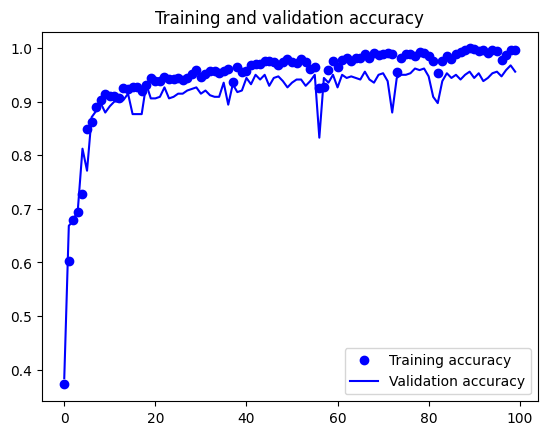

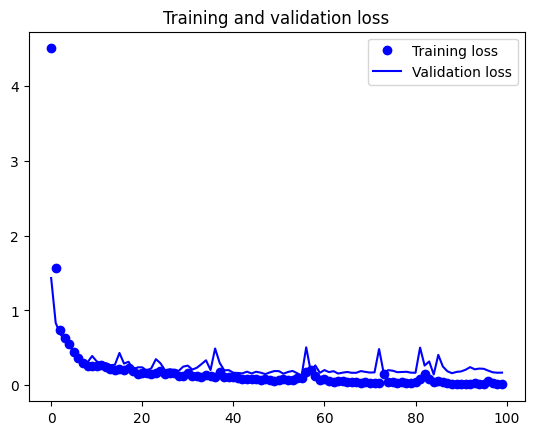

In [ ]:
accuracy_cor = cor_train.history['accuracy']
val_accuracy_cor = cor_train.history['val_accuracy']
loss_cor = cor_train.history['loss']
val_loss_cor = cor_train.history['val_loss']
epochs_cor = range(len(accuracy_cor))
plt.plot(epochs_cor, accuracy_cor, 'bo', label='Training accuracy')
plt.plot(epochs_cor, val_accuracy_cor, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs_cor, loss_cor, 'bo', label='Training loss')
plt.plot(epochs_cor, val_loss_cor, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
predicted_classes_cor = model_cor.predict(x_cor_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [ ]:
predicted_classes_cor = np.argmax(np.round(predicted_classes_cor),axis=1)

In [ ]:
predicted_classes_cor.shape, y_cor_test.shape

((427,), (427,))

408


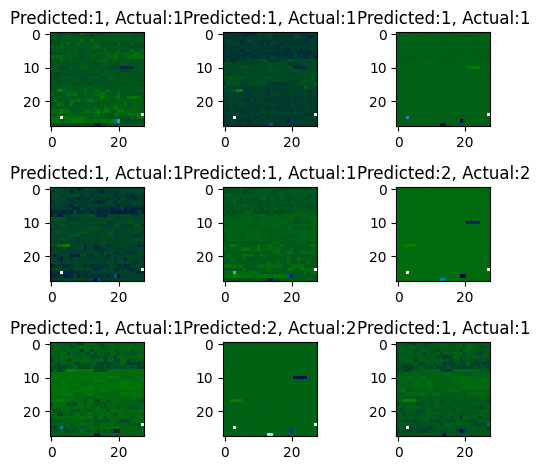

In [ ]:
correct_cor = np.where(predicted_classes_cor==y_cor_test)[0]
print(len(correct_cor))
for i, correct_cor in enumerate(correct_cor[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(x_cor_test[correct_cor].reshape(28,28), cmap='ocean', interpolation='none')
    plt.title("Predicted:{}, Actual:{}".format(predicted_classes_cor[correct_cor], y_cor_test[correct_cor]))
    plt.tight_layout()

19


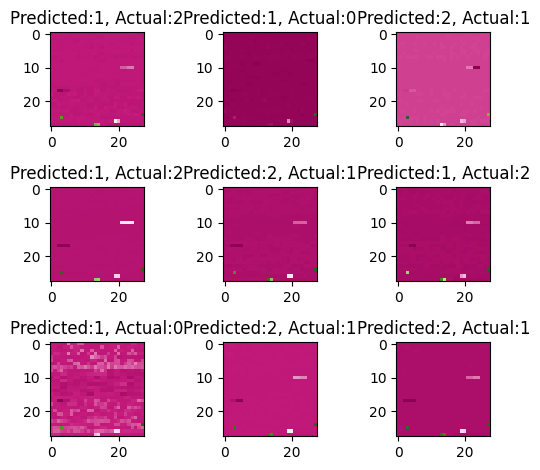

In [ ]:
incorrect_cor = np.where(predicted_classes_cor!=y_cor_test)[0]
print(len(incorrect_cor))
for i, incorrect_cor in enumerate(incorrect_cor[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(x_cor_test[incorrect_cor].reshape(28,28), cmap='PiYG', interpolation='none')
    plt.title("Predicted:{}, Actual:{}".format(predicted_classes_cor[incorrect_cor], y_cor_test[incorrect_cor]))
    plt.tight_layout()

In [ ]:
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(y_cor_test, predicted_classes_cor, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.98      0.97      0.98       153
     Class 1       0.92      0.95      0.93       142
     Class 2       0.97      0.94      0.95       132

    accuracy                           0.96       427
   macro avg       0.96      0.95      0.96       427
weighted avg       0.96      0.96      0.96       427



In [ ]:
print("Test Accuracy: {:.3f}%".format(test_cor_eval[1] * 100))

Test Accuracy: 95.550%
